# Notebook 11 — Forward Surrogate: MLP (A1)

**Goal**: Train a fully-connected DNN that maps **20 design parameters → 1000-point absorption spectrum** (1–1000 Hz).

This surrogate replaces the expensive Transfer Matrix Method (TMM) computation during inverse-design training loops.

| Aspect | Detail |
|--------|--------|
| **Input** | 20 normalised design parameters (d1–d10, m2/3/5/6/8/9, ρ, η, E, ν) |
| **Output** | 1000 absorption coefficients α(f), f ∈ [1, 1000] Hz |
| **Architecture** | 20 → 512 → 512 → 512 → 512 → 1000 (BatchNorm + LeakyReLU) |
| **Loss** | Frequency-weighted MSE (2× weight for 1–400 Hz) |
| **Data** | `lhs_data_full_spectrum.npz` — 1 M samples (LHS) |
| **Validation** | Cross-check against real TMM on held-out samples |

In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================
import sys, os, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Ensure src/ is importable
sys.path.insert(0, os.path.abspath('../src'))
from Theoretical_model import calculate_acoustic_properties
from physics_guided_CD_FiLM import PARAM_RANGES, validate_and_clip_parameters

# ---------- Device ----------
assert torch.cuda.is_available(), 'CUDA required'
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f'Device : {torch.cuda.get_device_name()}')

# ---------- Reproducibility ----------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------- Paths ----------
DATA_PATH   = '../data/lhs_data_full_spectrum.npz'
MODEL_DIR   = '../models'
MODEL_PATH  = os.path.join(MODEL_DIR, 'forward_surrogate_mlp.pth')
SCALER_PATH = os.path.join(MODEL_DIR, 'forward_surrogate_mlp_scaler.pkl')
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------- Hyper-parameters ----------
BATCH_SIZE   = 1024
EPOCHS       = 50
LR_INIT      = 1e-3
LR_MIN       = 1e-5
HIDDEN_DIM   = 512
NUM_PARAMS   = 20
NUM_FREQ     = 1000

PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']

print('\n✓ Imports & config ready')

Device : NVIDIA GeForce RTX 4050 Laptop GPU

✓ Imports & config ready


## Load Data & Train / Val / Test Split

In [2]:
# ============================================================
# Cell 2 — Load NPZ & split 80 / 10 / 10
# ============================================================
print('Loading NPZ …')
t0 = time.time()
raw = np.load(DATA_PATH)
params_all  = raw['params'].astype(np.float32)   # (1M, 20)
spectra_all = raw['spectra'].astype(np.float32)   # (1M, 1000)
frequencies = raw['frequencies']                   # (1000,)
print(f'  Loaded in {time.time()-t0:.1f}s  —  params {params_all.shape}, spectra {spectra_all.shape}')

# ---- Optional: subsample for faster dev (set to None to use all) ----
SUBSAMPLE = None   # e.g. 200_000 for quick experiments
if SUBSAMPLE is not None:
    idx = np.random.choice(len(params_all), SUBSAMPLE, replace=False)
    params_all, spectra_all = params_all[idx], spectra_all[idx]
    print(f'  Sub-sampled to {SUBSAMPLE:,}')

# ---- Split ----
X_train, X_temp, Y_train, Y_temp = train_test_split(
    params_all, spectra_all, test_size=0.2, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=SEED)

print(f'  Train : {X_train.shape[0]:>9,}')
print(f'  Val   : {X_val.shape[0]:>9,}')
print(f'  Test  : {X_test.shape[0]:>9,}')

# ---- Normalise parameters (MinMaxScaler fit on train only) ----
scaler_x = MinMaxScaler()
X_train_n = scaler_x.fit_transform(X_train)
X_val_n   = scaler_x.transform(X_val)
X_test_n  = scaler_x.transform(X_test)

# Spectra are already in [0, 1] (absorption coefficients) — no scaling needed

print(f'\n✓ Data ready  —  param range after scaling: [{X_train_n.min():.3f}, {X_train_n.max():.3f}]')

Loading NPZ …
  Loaded in 32.4s  —  params (1000000, 20), spectra (1000000, 1000)
  Train :   800,000
  Val   :   100,000
  Test  :   100,000

✓ Data ready  —  param range after scaling: [0.000, 1.000]


In [3]:
# ============================================================
# Cell 3 — Build DataLoaders
# ============================================================
def make_loader(X, Y, batch_size, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(Y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

train_loader = make_loader(X_train_n, Y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_n,   Y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_n,  Y_test,  BATCH_SIZE, shuffle=False)

print(f'✓ DataLoaders — {len(train_loader)} train batches, '
      f'{len(val_loader)} val batches, {len(test_loader)} test batches')

✓ DataLoaders — 782 train batches, 98 val batches, 98 test batches


## Model Architecture — `ForwardSurrogateMLP`

```
Input (20) → Linear(512) → BN → LeakyReLU
          → Linear(512) → BN → LeakyReLU
          → Linear(512) → BN → LeakyReLU
          → Linear(512) → BN → LeakyReLU
          → Linear(1000) → Sigmoid
Output (1000)   — absorption spectrum α(1 Hz) … α(1000 Hz)
```

In [4]:
# ============================================================
# Cell 4 — Model Definition
# ============================================================
class ForwardSurrogateMLP(nn.Module):
    """
    MLP forward surrogate: 20 design parameters → 1000-point absorption spectrum.
    """
    def __init__(self, in_dim=NUM_PARAMS, out_dim=NUM_FREQ,
                 hidden_dim=HIDDEN_DIM, num_layers=4, dropout=0.05):
        super().__init__()
        layers = []
        prev = in_dim
        for _ in range(num_layers):
            layers += [
                nn.Linear(prev, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Dropout(dropout),
            ]
            prev = hidden_dim
        layers.append(nn.Linear(hidden_dim, out_dim))
        layers.append(nn.Sigmoid())          # absorption ∈ [0, 1]
        self.net = nn.Sequential(*layers)

        # Initialise weights (Kaiming for LeakyReLU)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, a=0.01, nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = ForwardSurrogateMLP().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'✓ ForwardSurrogateMLP  —  {total_params:,} parameters')
print(model)

✓ ForwardSurrogateMLP  —  1,315,816 parameters
ForwardSurrogateMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01, inplace=True)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01, inplace=True)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01, inplace=True)
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReL

## Frequency-Weighted Loss

Low-frequency absorption (1–400 Hz) is physically harder to achieve and more valuable for
underwater coating design. We weight those frequencies **2×** in the MSE.

In [5]:
# ============================================================
# Cell 5 — Loss Function + Optimiser + Scheduler
# ============================================================
def build_freq_weights(num_freq=NUM_FREQ, low_cutoff=400, low_weight=2.0, device='cpu'):
    """Build per-frequency weight vector (higher weight for 1–400 Hz)."""
    w = torch.ones(num_freq, device=device)
    w[:low_cutoff] = low_weight
    w = w / w.mean()  # normalise so that mean weight = 1
    return w

freq_weights = build_freq_weights(device=device)

def weighted_mse_loss(pred, target, weights=freq_weights):
    """Frequency-weighted MSE."""
    diff_sq = (pred - target) ** 2          # (B, 1000)
    return (diff_sq * weights).mean()

optimizer = optim.Adam(model.parameters(), lr=LR_INIT, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

print(f'✓ Optimiser: Adam (lr={LR_INIT}), Scheduler: CosineAnnealing → {LR_MIN}')
print(f'  Freq weights: low-band (1–400 Hz) = {freq_weights[0].item():.3f}, '
      f'high-band (401–1000 Hz) = {freq_weights[400].item():.3f}')

✓ Optimiser: Adam (lr=0.001), Scheduler: CosineAnnealing → 1e-05
  Freq weights: low-band (1–400 Hz) = 1.429, high-band (401–1000 Hz) = 0.714


## Training Loop

In [6]:
# ============================================================
# Cell 6 — Training
# ============================================================
train_losses = []
val_losses   = []
best_val     = float('inf')
best_state   = None

print(f'Training {EPOCHS} epochs on {X_train.shape[0]:,} samples …\n')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ---------- Train ----------
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = weighted_mse_loss(pred, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    train_losses.append(epoch_loss / len(train_loader.dataset))

    # ---------- Validate ----------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += weighted_mse_loss(pred, yb).item() * xb.size(0)
    val_losses.append(val_loss / len(val_loader.dataset))

    scheduler.step()

    # ---------- Checkpoint ----------
    if val_losses[-1] < best_val:
        best_val   = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = ' ★'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch:3d}/{EPOCHS}  '
              f'train {train_losses[-1]:.6f}  val {val_losses[-1]:.6f}  '
              f'lr {lr_now:.2e}{tag}')

elapsed = time.time() - t_start
print(f'\n✓ Training complete in {elapsed/60:.1f} min  —  best val loss = {best_val:.6f}')

# Restore best weights
model.load_state_dict(best_state)
model.to(device)
print('  Best checkpoint restored')

Training 50 epochs on 800,000 samples …

  Epoch   1/50  train 0.002612  val 0.000594  lr 9.99e-04 ★
  Epoch   5/50  train 0.000516  val 0.000417  lr 9.76e-04
  Epoch  10/50  train 0.000502  val 0.000342  lr 9.05e-04
  Epoch  15/50  train 0.000475  val 0.000335  lr 7.96e-04
  Epoch  20/50  train 0.000436  val 0.000245  lr 6.58e-04 ★
  Epoch  25/50  train 0.000411  val 0.000339  lr 5.05e-04
  Epoch  30/50  train 0.000369  val 0.000230  lr 3.52e-04
  Epoch  35/50  train 0.000333  val 0.000362  lr 2.14e-04
  Epoch  40/50  train 0.000293  val 0.000247  lr 1.05e-04
  Epoch  45/50  train 0.000267  val 0.000220  lr 3.42e-05
  Epoch  50/50  train 0.000248  val 0.000203  lr 1.00e-05

✓ Training complete in 8.2 min  —  best val loss = 0.000174
  Best checkpoint restored


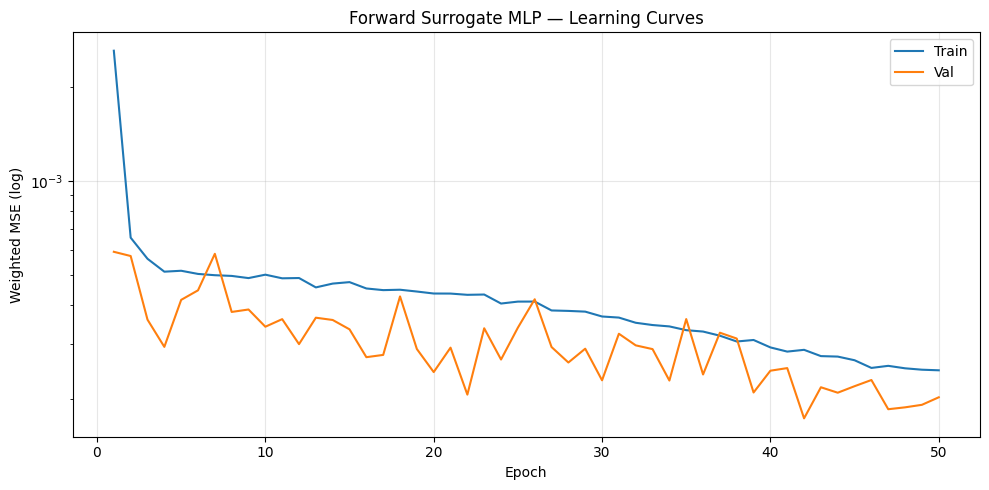

In [7]:
# ============================================================
# Cell 7 — Learning Curves
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(range(1, EPOCHS+1), train_losses, label='Train')
ax.semilogy(range(1, EPOCHS+1), val_losses,   label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE (log)')
ax.set_title('Forward Surrogate MLP — Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test-Set Evaluation

In [8]:
# ============================================================
# Cell 8 — Test-Set Metrics
# ============================================================
model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        all_preds.append(pred)
        all_trues.append(yb.numpy())

preds = np.concatenate(all_preds, axis=0)   # (N_test, 1000)
trues = np.concatenate(all_trues, axis=0)

# Per-frequency MSE
per_freq_mse = np.mean((preds - trues)**2, axis=0)    # (1000,)
# Overall spectral MSE
overall_mse  = per_freq_mse.mean()
# Max absolute error per sample, then average
max_abs_err  = np.max(np.abs(preds - trues), axis=1).mean()
# Average absorption error
avg_pred = preds.mean(axis=1)
avg_true = trues.mean(axis=1)
avg_abs_err = np.mean(np.abs(avg_pred - avg_true))
avg_rel_err = np.mean(np.abs(avg_pred - avg_true) / (avg_true + 1e-8)) * 100
# R² score (per-frequency, then averaged)
ss_res = np.sum((trues - preds)**2, axis=0)
ss_tot = np.sum((trues - trues.mean(axis=0, keepdims=True))**2, axis=0)
r2_per_freq = 1 - ss_res / (ss_tot + 1e-8)
r2_mean = r2_per_freq.mean()

print('═══════════════════════════════════════════')
print('  TEST SET METRICS (Forward Surrogate MLP)')
print('═══════════════════════════════════════════')
print(f'  Overall spectral MSE      : {overall_mse:.6e}')
print(f'  Mean max-abs error / sample: {max_abs_err:.4f}')
print(f'  Avg absorption abs error   : {avg_abs_err:.6f}')
print(f'  Avg absorption rel error   : {avg_rel_err:.2f} %')
print(f'  Mean R² (per-frequency)    : {r2_mean:.6f}')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
  TEST SET METRICS (Forward Surrogate MLP)
═══════════════════════════════════════════
  Overall spectral MSE      : 1.970426e-04
  Mean max-abs error / sample: 0.0287
  Avg absorption abs error   : 0.006067
  Avg absorption rel error   : 1.99 %
  Mean R² (per-frequency)    : 0.989751
═══════════════════════════════════════════


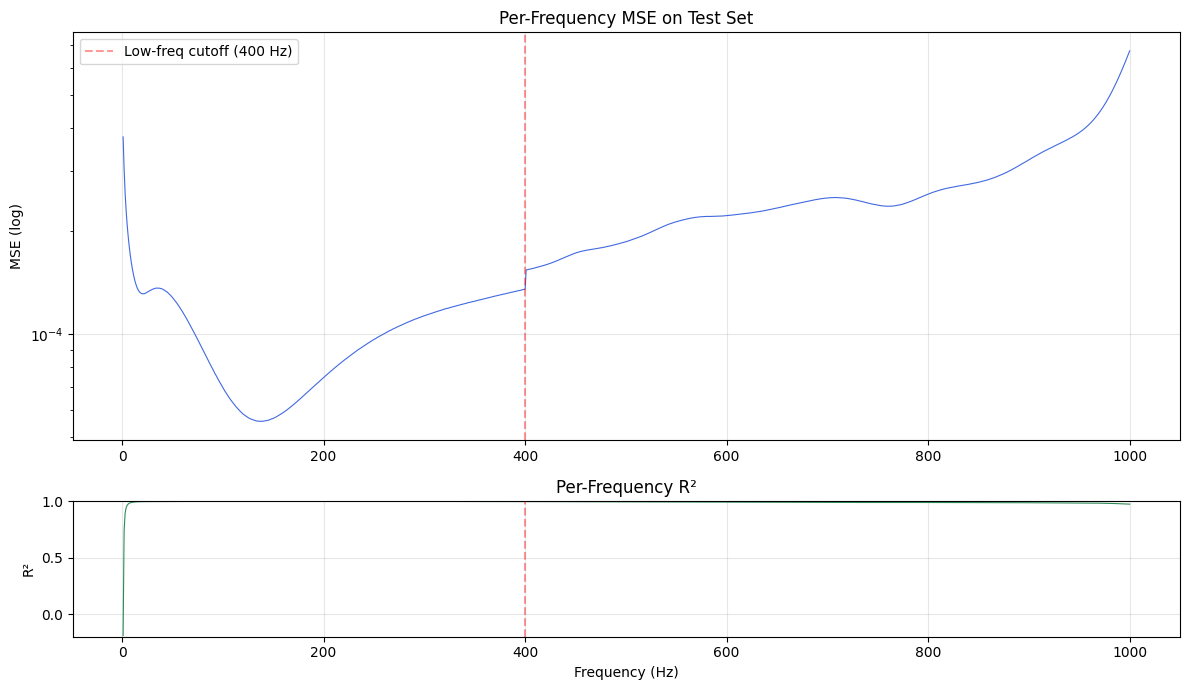

In [9]:
# ============================================================
# Cell 9 — Per-Frequency MSE Plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1])

ax1.semilogy(frequencies, per_freq_mse, color='royalblue', linewidth=0.8)
ax1.set_ylabel('MSE (log)')
ax1.set_title('Per-Frequency MSE on Test Set')
ax1.axvline(400, color='red', ls='--', alpha=0.4, label='Low-freq cutoff (400 Hz)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(frequencies, r2_per_freq, color='seagreen', linewidth=0.8)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('R²')
ax2.set_title('Per-Frequency R²')
ax2.set_ylim(min(0.9, r2_per_freq.min() - 0.01), 1.001)
ax2.axvline(400, color='red', ls='--', alpha=0.4)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

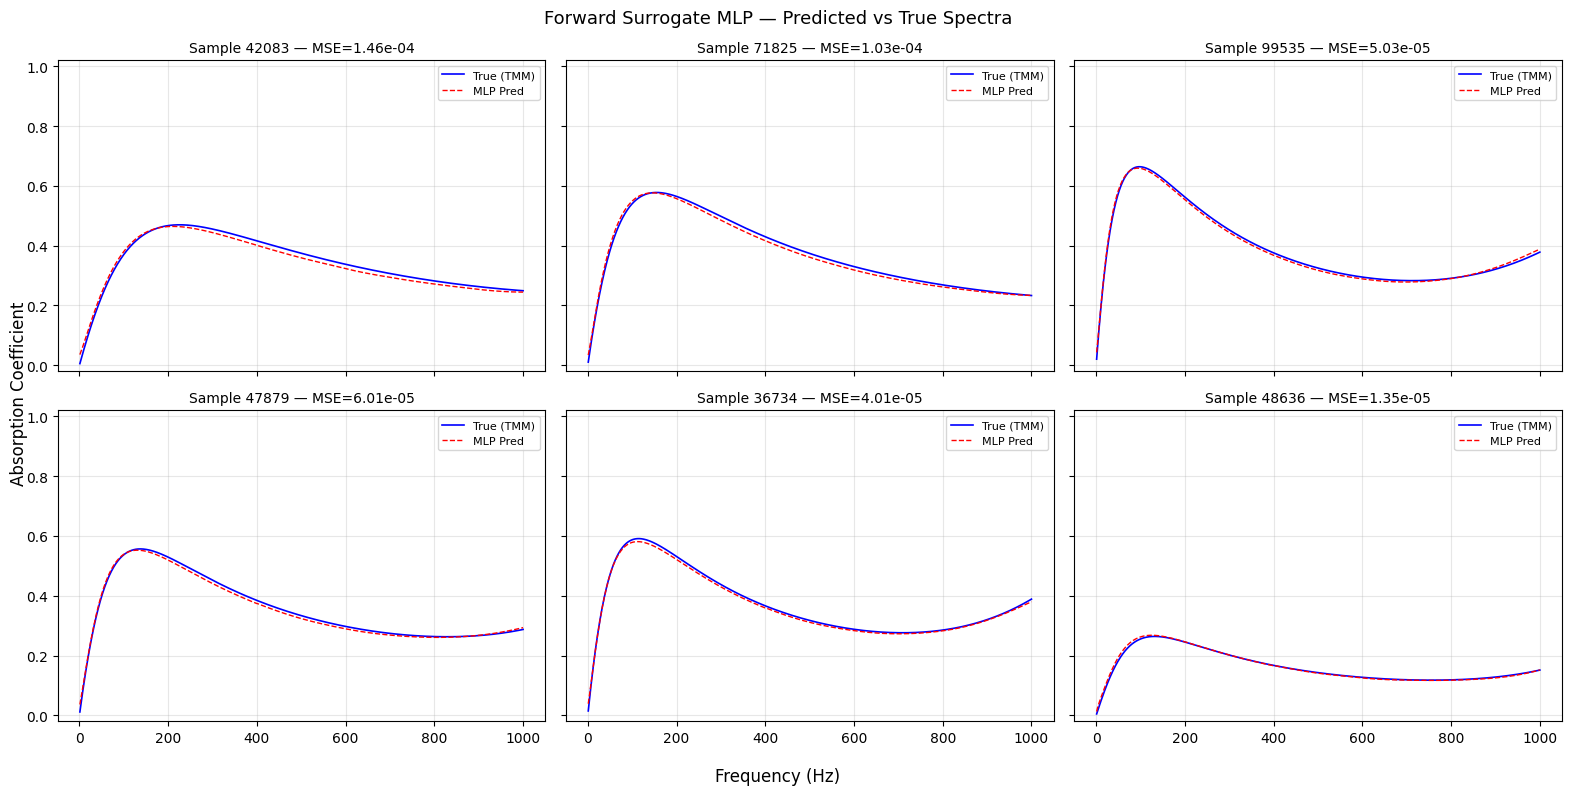

In [10]:
# ============================================================
# Cell 10 — Overlay: 6 Random Test Spectra (Predicted vs True)
# ============================================================
np.random.seed(123)
sample_idx = np.random.choice(len(preds), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, idx in zip(axes.flat, sample_idx):
    ax.plot(frequencies, trues[idx], 'b-',  linewidth=1.2, label='True (TMM)')
    ax.plot(frequencies, preds[idx], 'r--', linewidth=1.0, label='MLP Pred')
    mse_i = np.mean((trues[idx] - preds[idx])**2)
    ax.set_title(f'Sample {idx} — MSE={mse_i:.2e}', fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('Forward Surrogate MLP — Predicted vs True Spectra', fontsize=13)
plt.tight_layout()
plt.show()

## Cross-Validation Against Real TMM

The surrogate is trained on pre-computed TMM data. Here we **directly call the TMM physics engine** on
a few test samples and compare with the MLP prediction to verify surrogate fidelity.

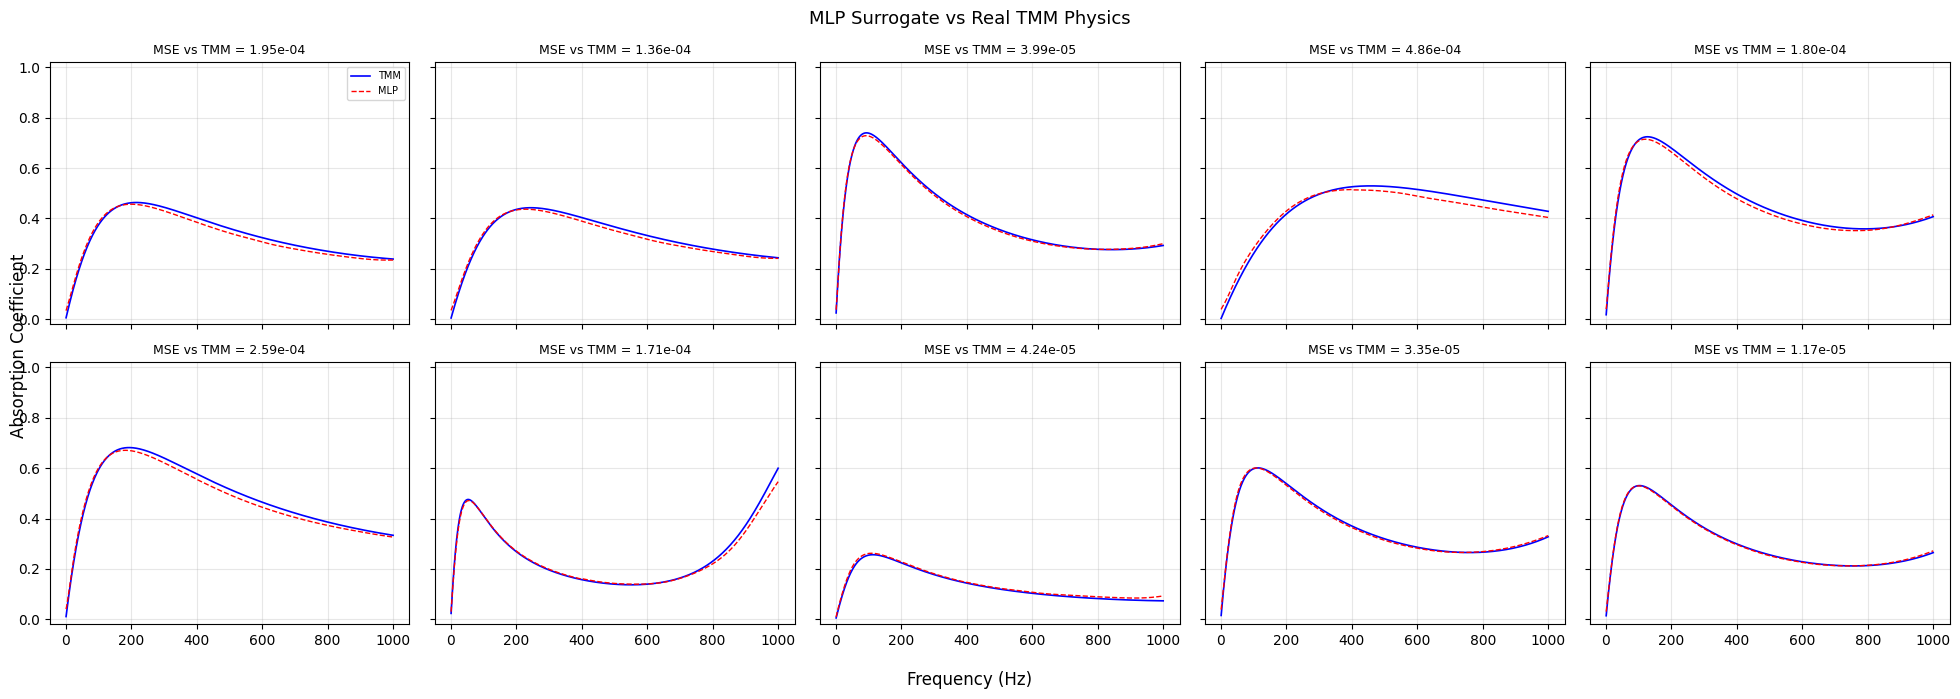


Mean MSE (Surrogate vs TMM)      : 1.554177e-04
Mean MSE (Surrogate vs Dataset)  : 1.554173e-04
Max MSE  (Surrogate vs TMM)      : 4.859312e-04


In [11]:
# ============================================================
# Cell 11 — TMM Cross-Validation (10 samples)
# ============================================================
NUM_TMM_CHECKS = 10
np.random.seed(77)
tmm_idx = np.random.choice(len(X_test), NUM_TMM_CHECKS, replace=False)

tmm_mse_list   = []
surr_mse_list  = []

fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=True, sharey=True)

for ax, idx in zip(axes.flat, tmm_idx):
    raw_params = X_test[idx]  # un-normalised original params

    # --- Real TMM ---
    param_dict = {
        'rho': float(raw_params[16]),
        'eta': float(raw_params[17]),
        'E':   float(raw_params[18]),
        'nu':  float(raw_params[19]),
        'W':   2000.0,
        'd':   [float(raw_params[i]) for i in range(10)],
        'm':   {2: float(raw_params[10]), 3: float(raw_params[11]),
                5: float(raw_params[12]), 6: float(raw_params[13]),
                8: float(raw_params[14]), 9: float(raw_params[15])}
    }
    _, alpha_tmm, _, _ = calculate_acoustic_properties(param_dict)

    # --- Surrogate prediction ---
    x_norm = scaler_x.transform(raw_params.reshape(1, -1))
    with torch.no_grad():
        alpha_surr = model(torch.tensor(x_norm, dtype=torch.float32, device=device)).cpu().numpy().flatten()

    # --- Ground truth from dataset ---
    alpha_data = Y_test[idx]

    tmm_mse  = np.mean((alpha_surr - alpha_tmm)**2)
    data_mse = np.mean((alpha_surr - alpha_data)**2)
    tmm_mse_list.append(tmm_mse)
    surr_mse_list.append(data_mse)

    ax.plot(frequencies, alpha_tmm,  'b-',  lw=1.2, label='TMM')
    ax.plot(frequencies, alpha_surr, 'r--', lw=1.0, label='MLP')
    ax.set_title(f'MSE vs TMM = {tmm_mse:.2e}', fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    if idx == tmm_idx[0]:
        ax.legend(fontsize=7)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('MLP Surrogate vs Real TMM Physics', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nMean MSE (Surrogate vs TMM)      : {np.mean(tmm_mse_list):.6e}')
print(f'Mean MSE (Surrogate vs Dataset)  : {np.mean(surr_mse_list):.6e}')
print(f'Max MSE  (Surrogate vs TMM)      : {np.max(tmm_mse_list):.6e}')

## Error Distribution Analysis

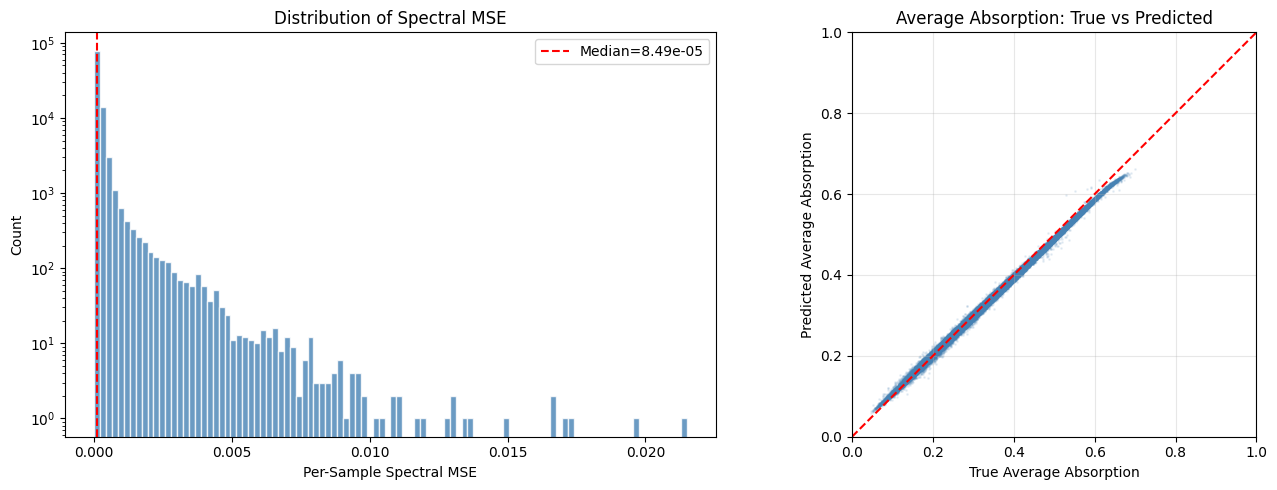

  50th percentile MSE: 8.49e-05
  90th percentile MSE: 3.53e-04
  95th percentile MSE: 5.68e-04
  99th percentile MSE: 2.38e-03


In [12]:
# ============================================================
# Cell 12 — Error Distribution
# ============================================================
sample_mse = np.mean((preds - trues)**2, axis=1)   # (N_test,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of per-sample MSE
ax1.hist(sample_mse, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.median(sample_mse), color='red', ls='--', label=f'Median={np.median(sample_mse):.2e}')
ax1.set_xlabel('Per-Sample Spectral MSE')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Spectral MSE')
ax1.legend()
ax1.set_yscale('log')

# Scatter: avg absorption true vs predicted
ax2.scatter(avg_true, avg_pred, s=1, alpha=0.1, c='steelblue')
ax2.plot([0, 1], [0, 1], 'r--', lw=1.5)
ax2.set_xlabel('True Average Absorption')
ax2.set_ylabel('Predicted Average Absorption')
ax2.set_title('Average Absorption: True vs Predicted')
ax2.set_aspect('equal')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Percentiles
for p in [50, 90, 95, 99]:
    print(f'  {p}th percentile MSE: {np.percentile(sample_mse, p):.2e}')

## Save Model & Scaler

In [13]:
# ============================================================
# Cell 13 — Save
# ============================================================
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'architecture': {
        'in_dim': NUM_PARAMS,
        'out_dim': NUM_FREQ,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': 4,
        'dropout': 0.05,
    },
    'train_loss': train_losses,
    'val_loss': val_losses,
    'best_val_loss': best_val,
    'test_metrics': {
        'spectral_mse': float(overall_mse),
        'mean_max_abs_err': float(max_abs_err),
        'avg_absorption_abs_err': float(avg_abs_err),
        'avg_absorption_rel_err_pct': float(avg_rel_err),
        'mean_r2': float(r2_mean),
    },
}, MODEL_PATH)

# Save scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler_x, f)

print(f'✓ Model saved → {MODEL_PATH}')
print(f'✓ Scaler saved → {SCALER_PATH}')
print(f'  File size: {os.path.getsize(MODEL_PATH)/1e6:.1f} MB')

✓ Model saved → ../models\forward_surrogate_mlp.pth
✓ Scaler saved → ../models\forward_surrogate_mlp_scaler.pkl
  File size: 5.3 MB


## Quick-Load Verification

Verify the saved model can be loaded and reproduces the same predictions.

In [ ]:
# ============================================================
# Cell 14 — Reload & Verify
# ============================================================
# Load model from disk
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
arch = ckpt['architecture']

model_loaded = ForwardSurrogateMLP(
    in_dim=arch['in_dim'], out_dim=arch['out_dim'],
    hidden_dim=arch['hidden_dim'], num_layers=arch['num_layers'],
    dropout=arch['dropout']
).to(device)
model_loaded.load_state_dict(ckpt['model_state_dict'])
model_loaded.eval()

# Load scaler
with open(SCALER_PATH, 'rb') as f:
    scaler_loaded = pickle.load(f)

# Verify on first 5 test samples
x_check = scaler_loaded.transform(X_test[:5])
with torch.no_grad():
    p1 = model(torch.tensor(x_check, dtype=torch.float32, device=device)).cpu().numpy()
    p2 = model_loaded(torch.tensor(x_check, dtype=torch.float32, device=device)).cpu().numpy()

max_diff = np.max(np.abs(p1 - p2))
print(f'✓ Reload check — max prediction difference: {max_diff:.2e} (should be ~0)')
print(f'  Saved test metrics: {ckpt["test_metrics"]}')

---

## Summary

| Metric | Value |
|--------|-------|
| Architecture | MLP: 20 → 512×4 → 1000 |
| Training samples | 800,000 |
| Loss | Frequency-weighted MSE (2× for 1–400 Hz) |
| Best val loss | *(see above)* |
| Test spectral MSE | *(see above)* |
| Test R² | *(see above)* |

**Saved artefacts:**
- `models/forward_surrogate_mlp.pth` — model weights + architecture config + metrics
- `models/forward_surrogate_mlp_scaler.pkl` — fitted MinMaxScaler for the 20 input parameters

**Next:** This surrogate is used by inverse-design notebooks 12–17 (A1 × B1–B6).